208
103
57
69
172
64
120
62
232
230
344
110
400
88
183
400
77
45
81
400
64
65
400
278
295
45
46
106
50
48
149
92
173
99
86
400
55
95
400
97
62
84
112
98
64
77
95
101
400
43
54
251
71
400
65
82
48
102
271
60
61
85
89
60
48
151
58
59
400
201
58
400
73
400
48
72
69
55
104
400
400
400
77
94
54
228
337
400
400
70
92
47
400
76
400
85
56
138
75
54
264
189
173
68
42
400
400
400
400
99
206
55
83
52
57
88
400
131
71
400
45
63
61
165
44
115
86
81
50
200
93
70
56
103
134
64
53
400
74
89
71
100
170
400
400
42
94
67
400
239
54
400
70
400
152
120
65
64
129
60
283
400
47
400
166
400
42
44
60
140
400
73
400
212
400
173
400
61
52
52
400
400
57
44
60
48
68
51
400
117
75
102
79
82
75
50
400
268
73
79
91
191
400
94
87
274
51
400
103
105
68
59
55
202
95
94
254
66
70
400
92
206
58
44
99
89
201
62
47
46
72
99
54
400
400
62
66
118
58
50
148
400
115
47
45
400
81
400
196
42
152
400
400
50
48
400
47
43
400
57
400
44
76
178
68
57
46
65
97
138
50
163
400
72
230
163
400
70
51
90
400
51
400
400
66
225
400
52
160
400


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


42
400


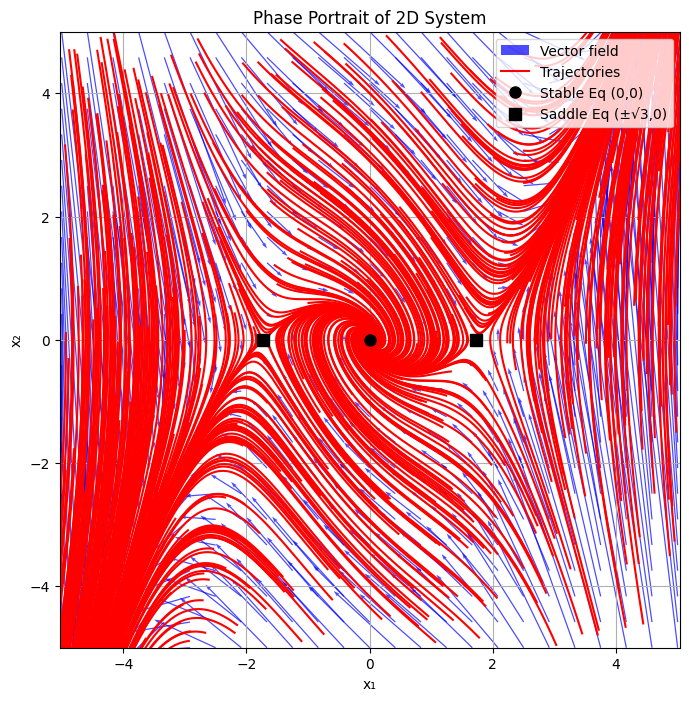

Generated 600 random trajectories


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Dynamics
def f1(x1, x2):
    return x2

def f2(x1, x2):
    return -x1 + (1/3)*x1**3 - x2

# Set up grid
x1_range = np.linspace(-5, 5, 25)
x2_range = np.linspace(-5, 5, 25)

x1, x2 = np.meshgrid(x1_range, x2_range)

# Evaluate derivatives
U = f1(x1, x2)
V = f2(x1, x2)

# Plot vector field
plt.figure(figsize=(8, 8))
quiv = plt.quiver(
    x1, x2, U, V,
    color='b',
    alpha=0.7,
    angles='xy',
    scale_units='xy',
    scale=5,
    width=0.002          
)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Phase Portrait of 2D System')
plt.axis('equal')
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.grid(True)

# Generate random initial conditions
num_trajectories = 600  # Change this to whatever you want
np.random.seed(42)  # For reproducibility; remove for different patterns each run

ics = np.random.uniform(-5, 5, size=(num_trajectories, 2))

# Define ODE system
def system(t, z):
    x1, x2 = z
    return [f1(x1, x2), f2(x1, x2)]

# Container for legend handles
lines = []

# Simulate trajectories for 6 seconds
t_span = [0, 6]
all_trajectories = []
for ic in ics:
    sol = solve_ivp(system, t_span, ic, t_eval=np.linspace(*t_span, 400))
    all_trajectories.append(sol.y[0])
    print(len(sol.y[0]))
    line, = plt.plot(sol.y[0], sol.y[1], 'r', linewidth=1.5)
    lines.append(line)

# Mark equilibria (0,0) and (+/- sqrt(3),0)
eq1 = plt.plot(0, 0, 'ko', markersize=8)
eq2 = plt.plot(3**0.5, 0, 'ks', markersize=8)
eq3 = plt.plot(-3**0.5, 0, 'ks', markersize=8)

# Custom legend
plt.legend(
    [quiv, lines[0], eq1[0], eq2[0]],
    ['Vector field', 'Trajectories', 'Stable Eq (0,0)', 'Saddle Eq (±√3,0)'],
    loc='upper right'
)

plt.show()

print(f"Generated {num_trajectories} random trajectories")

In [4]:
import torch.nn as nn
import math
import torch 
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class AttentionHead(nn.Module):
    def __init__(self, n_embd, head_size, dropout_rate):
        super().__init__()
        self.head_size = head_size
        self.w_key = nn.Linear(n_embd, head_size, bias=False)
        self.w_query = nn.Linear(n_embd, head_size, bias=False)
        self.w_value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        K = self.w_key(embedded_input)
        Q = self.w_query(embedded_input)
        V = self.w_value(embedded_input)
        raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(self.head_size))
        masked_attention_scores = raw_attention_scores.masked_fill(
            torch.tril(torch.ones(block_size, block_size)) == 0, float('-inf')
        )
        attention_probabilities = self.dropout(F.softmax(masked_attention_scores, dim=-1))
        return attention_probabilities @ V

class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.heads = nn.ModuleList([
            AttentionHead(n_embd, head_size, dropout_rate) for _ in range(num_heads)
        ])
        self.w_attn_output = nn.Linear(head_size * num_heads, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        head_outputs = [head(embedded_input, block_size) for head in self.heads]
        concatenated = torch.cat(head_outputs, dim=-1)
        return self.dropout(self.w_attn_output(concatenated))
    
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout_rate):
        super().__init__()
        self.w_ffn = nn.Linear(n_embd, 4 * n_embd)
        self.w_ffn_output = nn.Linear(4 * n_embd, n_embd)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        FFN_activations = F.relu(self.w_ffn(x))
        return self.dropout(self.w_ffn_output(FFN_activations))
    
class TransformerBlock(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.attention = MultiHeadAttention(n_embd, num_heads, head_size, dropout_rate)
        self.norm_attn_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
        self.ffn = FeedForward(n_embd, dropout_rate)
        self.norm_logits_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
    
    def forward(self, embedded_input, block_size):
        # Attention
        attention_output = self.attention(embedded_input, block_size)
        # Add + Norm
        FFN_in_raw = attention_output + embedded_input
        FFN_in_normalized = self.norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + self.norm_attn_bias
        # FFN
        FFN_output = self.ffn(FFN_in_normalized)
        # Add + Norm
        logits_raw = FFN_output + FFN_in_normalized
        logits_normalized = self.norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + self.norm_logits_bias
        return logits_normalized


class TransformerModel(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate, num_layers=1):
        super().__init__()
        self.embed = nn.Linear(1, n_embd, bias=False)
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embd, num_heads, head_size, dropout_rate) for _ in range(num_layers)
        ])
        self.w_logits_output = nn.Linear(n_embd, 1)
    
    def forward(self, input_data, block_size):
        embedded_input = self.embed(input_data)
        x = embedded_input
        for block in self.blocks:
            x = block(x, block_size)
        # Linear
        logits = self.w_logits_output(x)
        return logits


# Train Model
block_size = 7
n_embd = 7
num_heads = 5 # must be factor of 10 (block size)
head_size = n_embd // num_heads
dropout_rate = 0.2
num_layers = 5
model = TransformerModel(n_embd, num_heads, head_size, dropout_rate, num_layers)
optimizer = optim.Adam(model.parameters(), lr=0.001)
n_epochs = 3

# Prep Data
inputs = []
for trajectory in all_trajectories:
    for i in range(len(trajectory) - block_size):
        inputs.append(trajectory[i:i + block_size + 1])
training_inputs = inputs[:int(len(inputs)*.75)]
test_inputs = inputs[int(len(inputs)*.75):]
training_dataset = TensorDataset(torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in training_inputs]))
train_loader = DataLoader(training_dataset, batch_size=32, shuffle=True)

for epoch in range(n_epochs):
    epoch_loss = 0
    for batch in train_loader:
        input_sequences = batch[0]  # Shape: (batch_size, block_size + 1)
        input_data = input_sequences[:, :block_size].unsqueeze(-1)  # Shape: (batch_size, block_size, 1)
        targets = input_sequences[:, -1]  # Shape: (batch_size,)
        
        
        logits = model(input_data, block_size)

        # Backpropagation
        predictions = logits[:, -1, 0]  # Shape: (batch_size,)
        loss = F.mse_loss(predictions, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch}, Loss: {epoch_loss / len(training_inputs):.6f}")

total_params = sum(p.numel() for p in model.parameters())
for i, (name, p) in enumerate(model.named_parameters()):
    print(f"Param {i} ({name}): {p.numel()} parameters, shape: {p.shape}")
print(f"\nTotal parameters: {total_params}")

Epoch 0, Loss: 5197.192623
Epoch 1, Loss: 5245.460597
Epoch 2, Loss: 5261.465011
Param 0 (embed.weight): 7 parameters, shape: torch.Size([7, 1])
Param 1 (blocks.0.norm_attn_gain): 7 parameters, shape: torch.Size([7])
Param 2 (blocks.0.norm_attn_bias): 7 parameters, shape: torch.Size([7])
Param 3 (blocks.0.norm_logits_gain): 7 parameters, shape: torch.Size([7])
Param 4 (blocks.0.norm_logits_bias): 7 parameters, shape: torch.Size([7])
Param 5 (blocks.0.attention.heads.0.w_key.weight): 7 parameters, shape: torch.Size([1, 7])
Param 6 (blocks.0.attention.heads.0.w_query.weight): 7 parameters, shape: torch.Size([1, 7])
Param 7 (blocks.0.attention.heads.0.w_value.weight): 7 parameters, shape: torch.Size([1, 7])
Param 8 (blocks.0.attention.heads.1.w_key.weight): 7 parameters, shape: torch.Size([1, 7])
Param 9 (blocks.0.attention.heads.1.w_query.weight): 7 parameters, shape: torch.Size([1, 7])
Param 10 (blocks.0.attention.heads.1.w_value.weight): 7 parameters, shape: torch.Size([1, 7])
Param 11

In [5]:
import torch.nn as nn
import math
import torch 
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class AttentionHead(nn.Module):
    def __init__(self, n_embd, head_size, dropout_rate):
        super().__init__()
        self.head_size = head_size
        self.w_key = nn.Linear(n_embd, head_size, bias=False)
        self.w_query = nn.Linear(n_embd, head_size, bias=False)
        self.w_value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        K = self.w_key(embedded_input)
        Q = self.w_query(embedded_input)
        V = self.w_value(embedded_input)
        raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(self.head_size))
        masked_attention_scores = raw_attention_scores.masked_fill(
            torch.tril(torch.ones(block_size, block_size)) == 0, float('-inf')
        )
        attention_probabilities = self.dropout(F.softmax(masked_attention_scores, dim=-1))
        return attention_probabilities @ V

class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.heads = nn.ModuleList([
            AttentionHead(n_embd, head_size, dropout_rate) for _ in range(num_heads)
        ])
        self.w_attn_output = nn.Linear(head_size * num_heads, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        head_outputs = [head(embedded_input, block_size) for head in self.heads]
        concatenated = torch.cat(head_outputs, dim=-1)
        return self.dropout(self.w_attn_output(concatenated))
    
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout_rate):
        super().__init__()
        self.w_ffn = nn.Linear(n_embd, 4 * n_embd)
        self.w_ffn_output = nn.Linear(4 * n_embd, n_embd)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        FFN_activations = F.relu(self.w_ffn(x))
        return self.dropout(self.w_ffn_output(FFN_activations))
    
class TransformerBlock(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.attention = MultiHeadAttention(n_embd, num_heads, head_size, dropout_rate)
        self.norm_attn_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
        self.ffn = FeedForward(n_embd, dropout_rate)
        self.norm_logits_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
    
    def forward(self, embedded_input, block_size):
        # Attention
        attention_output = self.attention(embedded_input, block_size)
        # Add + Norm
        FFN_in_raw = attention_output + embedded_input
        FFN_in_normalized = self.norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + self.norm_attn_bias
        # FFN
        FFN_output = self.ffn(FFN_in_normalized)
        # Add + Norm
        logits_raw = FFN_output + FFN_in_normalized
        logits_normalized = self.norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + self.norm_logits_bias
        return logits_normalized


class TransformerModel(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate, num_layers=1):
        super().__init__()
        self.embed = nn.Linear(1, n_embd, bias=False)
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embd, num_heads, head_size, dropout_rate) for _ in range(num_layers)
        ])
        self.w_logits_output = nn.Linear(n_embd, 1)
    
    def forward(self, input_data, block_size):
        embedded_input = self.embed(input_data)
        x = embedded_input
        for block in self.blocks:
            x = block(x, block_size)
        # Linear
        logits = self.w_logits_output(x)
        return logits


# Train Model
block_size = 10
n_embd = 20
num_heads = 5 # must be factor of 10 (block size)
head_size = n_embd // num_heads
dropout_rate = 0.2
num_layers = 5
model = TransformerModel(n_embd, num_heads, head_size, dropout_rate, num_layers)
optimizer = optim.Adam(model.parameters(), lr=0.001)
n_epochs = 3

# Prep Data
inputs = []
for trajectory in all_trajectories:
    for i in range(len(trajectory) - block_size):
        inputs.append(trajectory[i:i + block_size + 1])
training_inputs = inputs[:int(len(inputs)*.75)]
test_inputs = inputs[int(len(inputs)*.75):]
training_dataset = TensorDataset(torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in training_inputs]))
train_loader = DataLoader(training_dataset, batch_size=32, shuffle=True)

for epoch in range(n_epochs):
    epoch_loss = 0
    for batch in train_loader:
        input_sequences = batch[0]  # Shape: (batch_size, block_size + 1)
        input_data = input_sequences[:, :block_size].unsqueeze(-1)  # Shape: (batch_size, block_size, 1)
        targets = input_sequences[:, -1]  # Shape: (batch_size,)
        
        
        logits = model(input_data, block_size)

        # Backpropagation
        predictions = logits[:, -1, 0]  # Shape: (batch_size,)
        loss = F.mse_loss(predictions, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch}, Loss: {epoch_loss / len(training_inputs):.6f}")

total_params = sum(p.numel() for p in model.parameters())
for i, (name, p) in enumerate(model.named_parameters()):
    print(f"Param {i} ({name}): {p.numel()} parameters, shape: {p.shape}")
print(f"\nTotal parameters: {total_params}")

Epoch 0, Loss: 5389.247123
Epoch 1, Loss: 5435.228482
Epoch 2, Loss: 5388.641635
Param 0 (embed.weight): 20 parameters, shape: torch.Size([20, 1])
Param 1 (blocks.0.norm_attn_gain): 20 parameters, shape: torch.Size([20])
Param 2 (blocks.0.norm_attn_bias): 20 parameters, shape: torch.Size([20])
Param 3 (blocks.0.norm_logits_gain): 20 parameters, shape: torch.Size([20])
Param 4 (blocks.0.norm_logits_bias): 20 parameters, shape: torch.Size([20])
Param 5 (blocks.0.attention.heads.0.w_key.weight): 80 parameters, shape: torch.Size([4, 20])
Param 6 (blocks.0.attention.heads.0.w_query.weight): 80 parameters, shape: torch.Size([4, 20])
Param 7 (blocks.0.attention.heads.0.w_value.weight): 80 parameters, shape: torch.Size([4, 20])
Param 8 (blocks.0.attention.heads.1.w_key.weight): 80 parameters, shape: torch.Size([4, 20])
Param 9 (blocks.0.attention.heads.1.w_query.weight): 80 parameters, shape: torch.Size([4, 20])
Param 10 (blocks.0.attention.heads.1.w_value.weight): 80 parameters, shape: torch.